In [ ]:


import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/heart-failure-prediction


In [ ]:
#Opening the csv
import pandas as pd
data_set_path = "/kaggle/input/heart-failure-prediction/heart.csv"
df = pd.read_csv(data_set_path)
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [ ]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

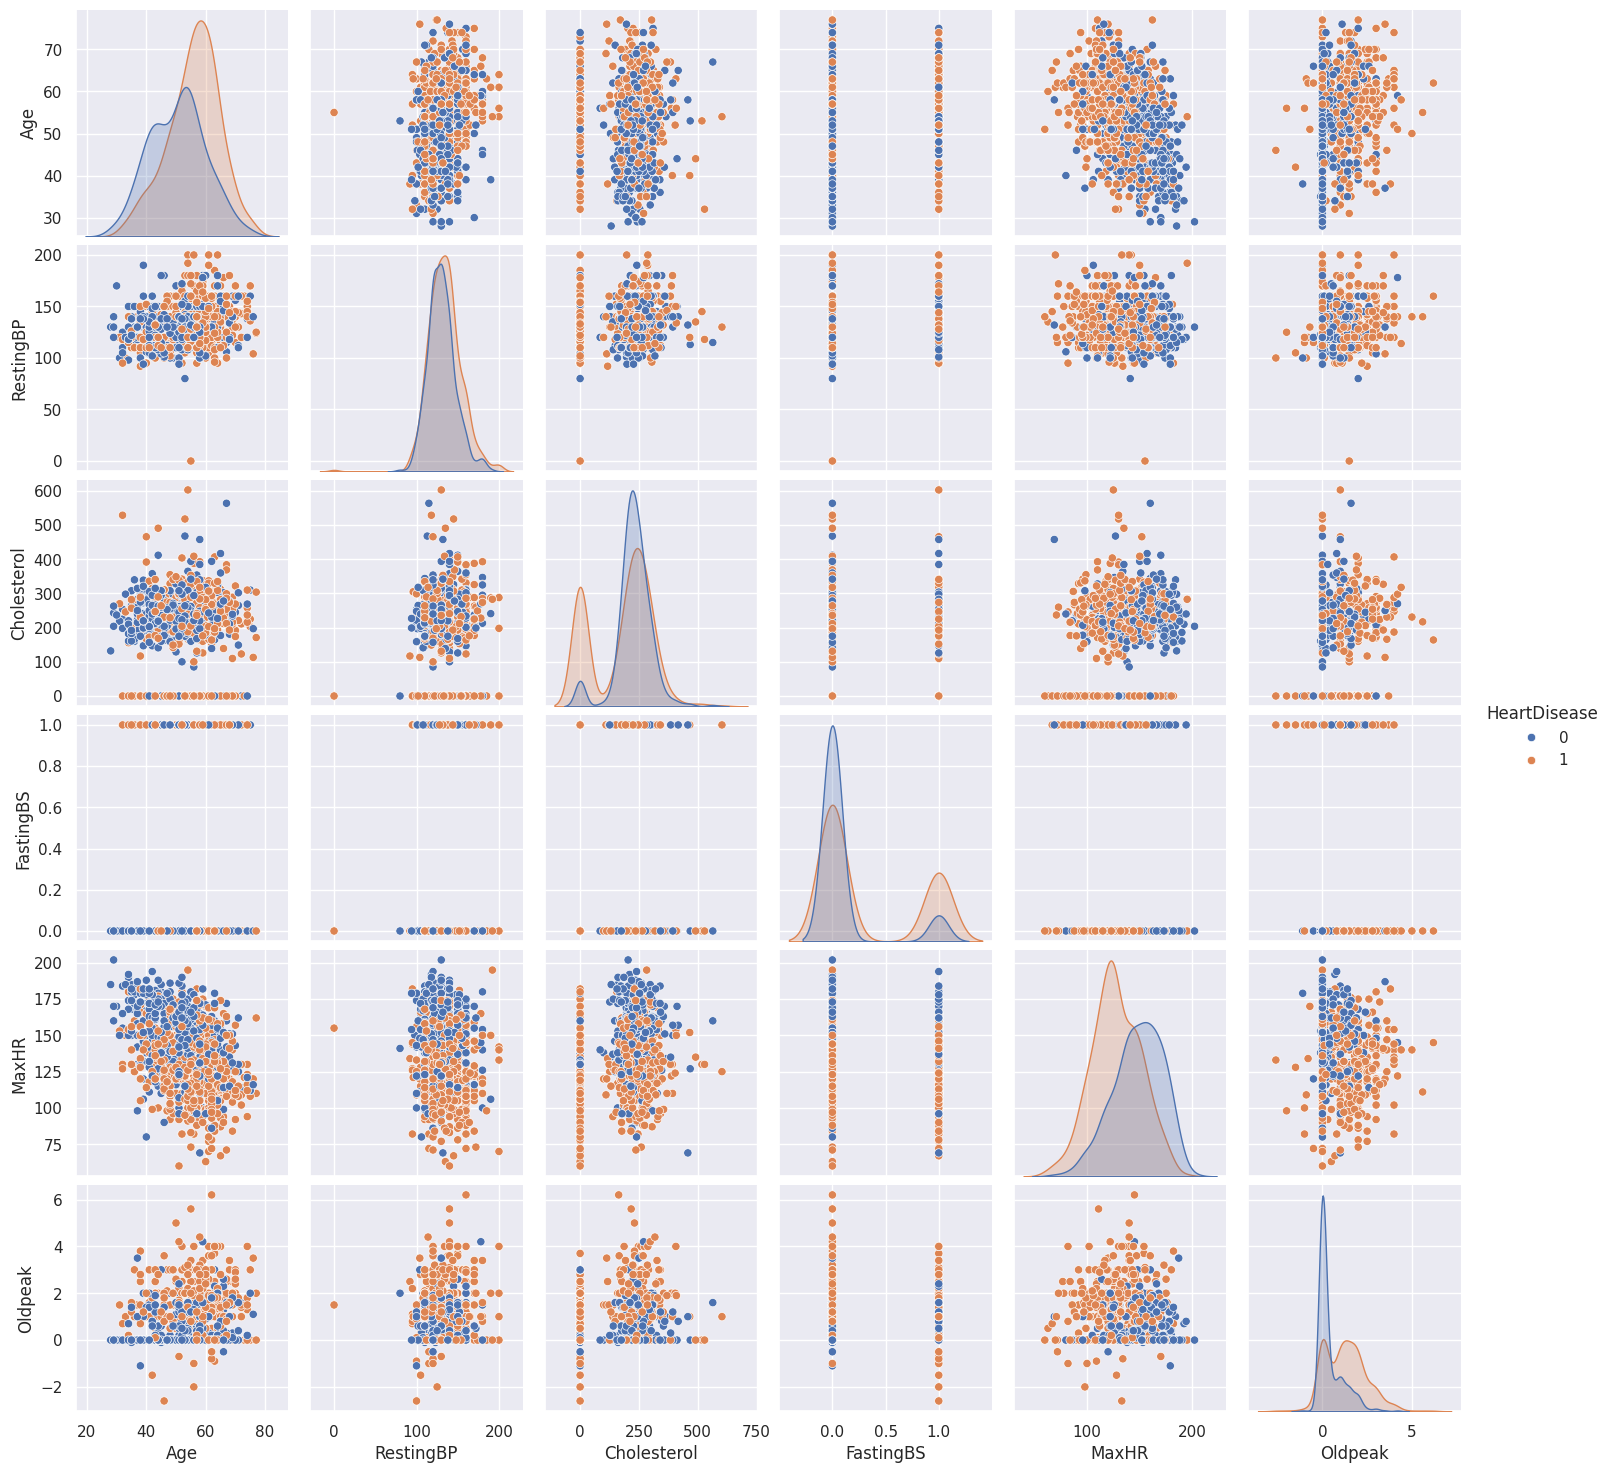

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
sns.pairplot(df, hue="HeartDisease")
plt.show()

<Axes: xlabel='HeartDisease'>

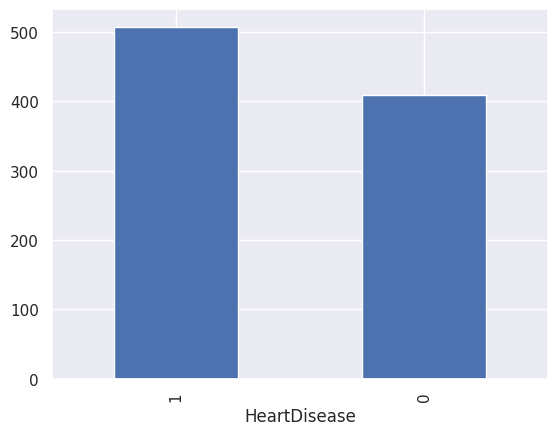

In [ ]:
df["HeartDisease"].value_counts().plot(kind="bar")

<Axes: ylabel='Frequency'>

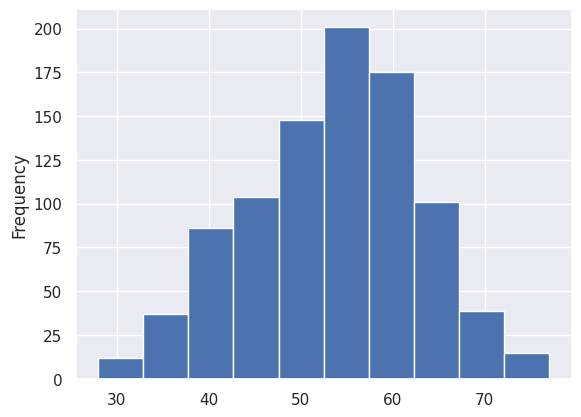

In [ ]:
df["Age"].plot(kind="hist")

In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
df.isnull().sum()
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout , Conv2D , MaxPooling2D , Flatten, BatchNormalization
from sklearn.preprocessing import StandardScaler
import numpy as np


In [ ]:
# prompt: give me code to split the data and use getdummies for the categorical data

import pandas as pd
# Define features (X) and target (y)
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify categorical columns (excluding the target)
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Apply one-hot encoding using get_dummies
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - this is important if one-hot encoding results in different columns in train and test sets
train_cols = X_train_encoded.columns
test_cols = X_test_encoded.columns
missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_encoded[c] = 0
missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_encoded[c] = 0
X_test_encoded = X_test_encoded[train_cols] # Ensure the order is the same

print("Shape of X_train_encoded:", X_train_encoded.shape)
print("Shape of X_test_encoded:", X_test_encoded.shape)
print("\nSample of X_train_encoded:")
print(X_train_encoded.head())
print("\nSample of X_test_encoded:")
print(X_test_encoded.head())

Shape of X_train_encoded: (734, 15)
Shape of X_test_encoded: (184, 15)

Sample of X_train_encoded:
     Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Sex_M  \
795   42        120          240          1    194      0.8   True   
25    36        130          209          0    178      0.0   True   
84    56        150          213          1    125      1.0   True   
10    37        130          211          0    142      0.0  False   
344   51        120            0          1    104      0.0   True   

     ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
795              False               True             False   
25               False               True             False   
84               False              False             False   
10               False               True             False   
344              False              False             False   

     RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  \
795               True     

In [ ]:
model = Sequential([
    Dense(2048, activation='relu', input_shape=(X_train_encoded.shape[1],)),
    Dropout(0.3),
    Dense(1024, activation='relu', input_shape=(X_train_encoded.shape[1],)),
    Dropout(0.3),
    Dense(512, activation='relu', input_shape=(X_train_encoded.shape[1],)),
    Dropout(0.3),
    Dense(256, activation='relu', input_shape=(X_train_encoded.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2048)           │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,828,289 (10.79 MB)

 Trainable params: 2,828,289 (10.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train_encoded, y_train, epochs=10, batch_size=32, validation_split=0.2)

In [ ]:
model.predict(X_test_encoded)

In [ ]:
# prompt: Use f1 score accuracy score to compare the result we have

from sklearn.metrics import f1_score, accuracy_score

# Make predictions on the test set
y_pred_proba = model.predict(X_test_encoded)
y_pred = (y_pred_proba > 0.5).astype("int32")

# Calculate Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy}")

# Calculate F1 Score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1}")

In [ ]:
# prompt: combine random forest ,logistic regression and svm to a single pipeline  to train the mdel and use confusion matrix , clearly labeled

import matplotlib.pyplot as plt
!pip install scikit-learn

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Preprocessing steps (assuming X_train_encoded and X_test_encoded are already created and scaled)
# If not scaled, you would add StandardScaler here within the pipeline

# Define the models
rf_model = RandomForestClassifier(random_state=42)
lr_model = LogisticRegression(random_state=42)
svm_model = SVC(probability=True, random_state=42) # probability=True is needed for some voting classifiers

# # Create pipelines for each model (can add preprocessing steps if needed)
# pipeline_rf = Pipeline([('random_forest', rf_model)])
# pipeline_lr = Pipeline([('logistic_regression', lr_model)])
# pipeline_svm = Pipeline([('svm', svm_model)])

# # Train each model
# pipeline_rf.fit(X_train_encoded, y_train)
# pipeline_lr.fit(X_train_encoded, y_train)
# pipeline_svm.fit(X_train_encoded, y_train)

# # Make predictions
# y_pred_rf = pipeline_rf.predict(X_test_encoded)
# y_pred_lr = pipeline_lr.predict(X_test_encoded)
# y_pred_svm = pipeline_svm.predict(X_test_encoded)

# # Evaluate and display confusion matrices

# print("Confusion Matrix - Random Forest:")
# cm_rf = confusion_matrix(y_test, y_pred_rf)
# disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
# disp_rf.plot()
# plt.title("Confusion Matrix - Random Forest")
# plt.show()

# print("\nConfusion Matrix - Logistic Regression:")
# cm_lr = confusion_matrix(y_test, y_pred_lr)
# disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
# disp_lr.plot()
# plt.title("Confusion Matrix - Logistic Regression")
# plt.show()

# print("\nConfusion Matrix - SVM:")
# cm_svm = confusion_matrix(y_test, y_pred_svm)
# disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
# disp_svm.plot()
# plt.title("Confusion Matrix - SVM")
# plt.show()

# Optional: Combine models using a Voting Classifier
from sklearn.ensemble import VotingClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Note: SVM needs probability=True for VotingClassifier with soft voting
voting_clf = VotingClassifier(estimators=[('rf', rf_model), ('lr', lr_model), ('svm', svm_model)], voting='hard') # Use 'soft' for probability based voting

voting_clf.fit(X_train_encoded, y_train)
y_pred_voting = voting_clf.predict(X_test_encoded)

print("\nConfusion Matrix - Voting Classifier:")
cm_voting = confusion_matrix(y_test, y_pred_voting)
disp_voting = ConfusionMatrixDisplay(confusion_matrix=cm_voting)
disp_voting.plot()
plt.title("Confusion Matrix - Voting Classifier")
plt.show()


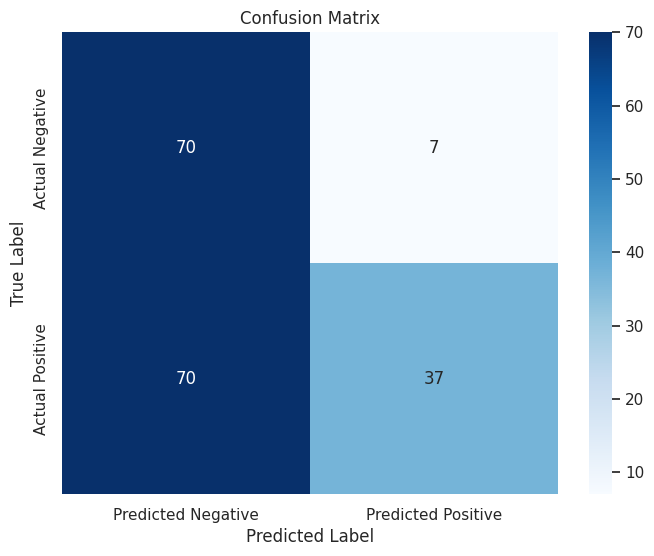

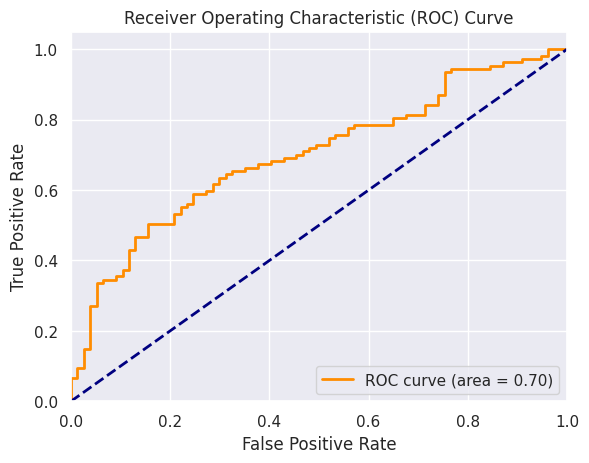

AUC: 0.7011773273455516


In [ ]:
# prompt: create a confusion matrix and lets see the AUC

from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Calculate AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

print(f"AUC: {roc_auc}")
